In [ ]:
!pip install unsloth -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 142.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 134.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

In [ ]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 1024
dtype = None
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3-8B-unsloth-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)
print("✅ Model yüklendi")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.8: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json:   0%|          | 0.00/144k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/4.67k [00:00<?, ?B/s]

unsloth/Qwen3-8B-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
✅ Model yüklendi


In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)
print("✅ LoRA adaptörleri eklendi")

Unsloth 2026.6.8 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


✅ LoRA adaptörleri eklendi


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
VERI_YOLU = "/content/drive/MyDrive/MindCoach_Ozetler/mindcoach_chatml.jsonl"

from datasets import load_dataset
dataset = load_dataset("json", data_files=VERI_YOLU, split="train")
print(f"✅ {len(dataset)} örnek yüklendi")
print("Örnek girdi:", dataset[0]["conversations"][1]["content"])

Mounted at /content/drive


Generating train split: 0 examples [00:00, ? examples/s]

✅ 489 örnek yüklendi
Örnek girdi: Kişilik: Tip 1 (Mükemmeliyetçi). Ruh hali: çok zorlanıyor. Zayıf konu: TYT Matematik - Temel Kavramlar.


In [ ]:
def formatla(ornekler):
    metinler = []
    for konusma in ornekler["conversations"]:
        metin = tokenizer.apply_chat_template(
            konusma, tokenize=False, add_generation_prompt=False,
            enable_thinking=False
        )
        metinler.append(metin)
    return {"text": metinler}

dataset = dataset.map(formatla, batched=True)
print("✅ Veri ChatML formatına uygulandı")
print(dataset[0]["text"][:300])

Map:   0%|          | 0/489 [00:00<?, ? examples/s]

✅ Veri ChatML formatına uygulandı
<|im_start|>system
Sen YKS öğrencilerine kişiselleştirilmiş, gerçekçi ve somut çalışma tavsiyeleri veren uzman bir koçsun. Öğrencinin kişilik tipine ve ruh haline göre ton ayarlar, zayıf olduğu konunun özüne inerek nasıl çalışması gerektiğini anlatırsın.<|im_end|>
<|im_start|>user
Kişilik: Tip 1 (Mü


In [ ]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    args = SFTConfig(
        dataset_text_field = "text",
        max_seq_length = max_seq_length,
        per_device_train_batch_size = 8,
        gradient_accumulation_steps = 2,
        warmup_steps = 5,
        num_train_epochs = 3,
        learning_rate = 2e-4,
        logging_steps = 5,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
    ),
)
print("✅ Trainer hazır")

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/489 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
✅ Trainer hazır


In [ ]:
trainer_stats = trainer.train()
print("✅ Eğitim tamamlandı")
print(f"Toplam süre: {trainer_stats.metrics['train_runtime']:.1f} saniye")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 489 | Num Epochs = 3 | Total steps = 93
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 43,646,976 of 8,234,382,336 (0.53% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
5,3.075028
10,2.295227
15,1.516980
20,1.193328
25,1.053097
30,0.992430
35,0.929469
40,0.934140
45,0.874389
50,0.850248


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-93/tokenizer_config.json.


✅ Eğitim tamamlandı
Toplam süre: 123.7 saniye


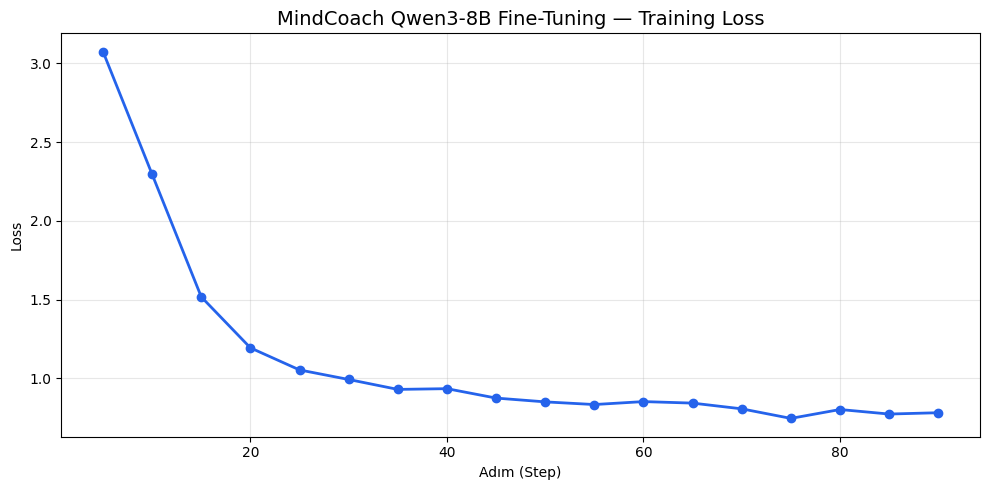

✅ Loss grafiği Drive'a kaydedildi


In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
adimlar = [x["step"] for x in log_history if "loss" in x]
kayiplar = [x["loss"] for x in log_history if "loss" in x]

plt.figure(figsize=(10, 5))
plt.plot(adimlar, kayiplar, marker='o', linewidth=2, color='#2563eb')
plt.title("MindCoach Qwen3-8B Fine-Tuning — Training Loss", fontsize=14)
plt.xlabel("Adım (Step)")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MindCoach_Ozetler/training_loss.png", dpi=120)
plt.show()
print("✅ Loss grafiği Drive'a kaydedildi")

In [ ]:
FastLanguageModel.for_inference(model)

test_girdileri = [
    "Kişilik: Tip 3 (Başarı Odaklı). Ruh hali: enerjik. Zayıf konu: TYT Matematik - Türev.",
    "Kişilik: Tip 5 (Araştırmacı). Ruh hali: çok zorlanıyor. Zayıf konu: TYT Fizik - Optik.",
    "Kişilik: Tip 8 (Meydan Okuyan). Ruh hali: dengeli. Zayıf konu: TYT Tarih - İnkılaplar.",
]

SISTEM = "Sen YKS öğrencilerine kişiselleştirilmiş, gerçekçi ve somut çalışma tavsiyeleri veren uzman bir koçsun. Öğrencinin kişilik tipine ve ruh haline göre ton ayarlar, zayıf olduğu konunun özüne inerek nasıl çalışması gerektiğini anlatırsın."

def cevap_uret(girdi):
    mesajlar = [
        {"role": "system", "content": SISTEM},
        {"role": "user", "content": girdi},
    ]
    g = tokenizer.apply_chat_template(
        mesajlar, tokenize=True, add_generation_prompt=True,
        enable_thinking=False, return_tensors="pt"
    ).to("cuda")
    c = model.generate(input_ids=g, max_new_tokens=220, temperature=0.7, do_sample=True)
    return tokenizer.decode(c[0][g.shape[1]:], skip_special_tokens=True).strip()

for i, girdi in enumerate(test_girdileri, 1):
    print("=" * 70)
    print(f"GİRDİ {i}: {girdi}")
    print("=" * 70)
    print("\n🟢 FINE-TUNE'LU MODEL:")
    print(cevap_uret(girdi))
    with model.disable_adapter():
        print("\n⚪ BASE QWEN3 (adaptörsüz):")
        print(cevap_uret(girdi))
    print("\n")

print("👆 Her girdi için FINE-TUNE vs BASE karşılaştır.")

Both `max_new_tokens` (=220) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GİRDİ 1: Kişilik: Tip 3 (Başarı Odaklı). Ruh hali: enerjik. Zayıf konu: TYT Matematik - Türev.

🟢 FINE-TUNE'LU MODEL:


Both `max_new_tokens` (=220) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Kök içi fonksiyonların türevini alırken, zincir kuralı kullanma kuralını öğren. İçteki fonksiyonun türevini alın, dıştaki fonksiyonun içteki fonksiyonun yerine yaz. Örneğin kök x'in türevi 1 bölü 2 kök x'tir, ancak kök içinde bir polinom varsa, o polinomun türevini içteki parantez içinde alırsın.

⚪ BASE QWEN3 (adaptörsüz):


Both `max_new_tokens` (=220) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Yansıma ve kırılma olayında kural arama zihnine güven. Yansıma yasasında gelen ışının normal ile yaptığı açının, yansıyan ışının normal ile yaptığı açının eşit olduğunu bilmek yeterlidir. Kırılma yasasında ise oranların eşitliği kritik bir kuraldır. Gelen ve kırılan ışınların ortak normal doğrusuna göre oluşturdukları açıların sinüslerinin oranı her zaman sabit bir değerdir.

⚪ BASE QWEN3 (adaptörsüz):


Both `max_new_tokens` (=220) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Merhaba! Senin gibi bir **Tip 5 (Araştırmacı)** öğrenciyi çok iyi biliyorum. Senin için her şey birer **soru** ve her soru bir **arama** olarak değerlendirilir. Ama şu an sen **çok zorlanıyorsun** ve özellikle **TYT Fizik - Optik** konusunda zayıf hissediyorsun. Bu durumda, sadece bilgiyi ezberlemek değil, **bilgiyi anlamak** ve **kendini sorgulamak** sürecini daha etkili hale getirmek gerekiyor.

---

### 🧠 Tip 5 (Araştırmacı) için Optik Konusunu Anlamak İçin İdeal Yaklaşım:

#### 1. **"Neden?" Sorusunu Sormaya Başla**
Senin için en güçlü noktası, **soruları sormak** ve **nedenleri aramak**


GİRDİ 3: Kişilik: Tip 8 (Meydan Okuyan). Ruh hali: dengeli. Zayıf konu: TYT Tarih - İnkılaplar.

🟢 FINE-TUNE'LU MODEL:


Both `max_new_tokens` (=220) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Kanunların sosyal adaleti yaratmak için ne kadar mekanik ve zorunlu olduğu gerçeğini kafanı karıştırmadan hisset. Medeni Kanun Kanunu, eşitlik ve bağımsızlık ilkelerini toplumun her kesimine yaymak için herkesin aynı hukuki statüye sahip olduğunu belirlemiştir. Din, ırk, cinsiyet ve sosyal statü gibi unsurların hukukla hiçbir ilgisi olmamasını savunur.

⚪ BASE QWEN3 (adaptörsüz):
Harika, senin gibi **Tip 8 (Meydan Okuyan)** ve **dengeli ruh hali**ye sahip bir öğrenciyle çalışmak gerçekten zengin bir deneyim. Tip 8’li öğrenciler genellikle **başkaları için savaşmak**, **kendini güçlü hissetmek**, ve **davranışlarını etkileyebilecek bir pozisyonda bulunmak** isteyen kişilik tipleridir. Bu özellikler, TYT Tarih - İnkılaplar gibi **tarihi olaylar ve etkilerini anlamak** konusunda **kuvvetli bir potansiyel** barındırır. Ancak, tarihi bilgiyi **sadece hatırlamak değil, anlamak ve bağlam içinde görmek** gerektiren bir konu olduğu için, bazı durumlarda **kavramsal zorluklar** yaşıyorsun. 

---

In [ ]:
KAYIT_YOLU = "/content/drive/MyDrive/MindCoach_Ozetler/mindcoach_qwen3_lora"
model.save_pretrained(KAYIT_YOLU)
tokenizer.save_pretrained(KAYIT_YOLU)
print(f"✅ LoRA adaptörü kaydedildi: {KAYIT_YOLU}")

✅ LoRA adaptörü kaydedildi: /content/drive/MyDrive/MindCoach_Ozetler/mindcoach_qwen3_lora
